# Regularized CCA (rCCA) and Clustering with IM-Biotype

Regularized Canonical Correlation Analysis (rCCA) finds linear combinations of two sets of variables that maximize their correlation, while adding a ridge penalty to prevent overfitting. This tutorial walks through an rCCA analysis of **EEG delta power** (56 channels) and **QIDS clinical symptoms** (16 items) using the IM-Biotype toolbox.

This notebook replicates a MATLAB workflow (`MP_rCCA_EEGandSymptoms.m`) and covers:
1. Data loading and inspection
2. Preprocessing (residualization, standardization)
3. Hyperparameter optimization (regularization grid search)
4. Permutation testing for statistical significance

## Setup & Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add lib to path so we can import imbiotype
repo_root = Path.cwd().parent  # assumes notebook is in tutorials/
sys.path.insert(0, str(repo_root / "lib"))

from imbiotype import Study
from imbiotype.models.fusion import FusionConfig, CCASettings, ModelSettings
from imbiotype.models.feature_processing import FeatureProcessingConfig
from imbiotype.processing.feature_processor import PreprocessingConfig

print("Imports OK")

Imports OK


## Configuration

Key parameters matching the MATLAB rCCA workflow:
- **K-fold CV**: 10-fold cross-validation for hyperparameter selection
- **Lambda grids**: regularization search space for X and Y views
- **Permutations**: number of permutation tests for statistical inference

Set `QUICK_TEST_MODE = False` and `training_nfit = 1000` for full replication.

In [2]:
# --- Quick test mode: True = fast (~minutes), False = full replication (~hours) ---
QUICK_TEST_MODE = True

# Paths
study_dir = repo_root / "tutorials" / "rcca_tutorial_study"
rcca_dir = repo_root / "matlab_adaptation" / "rcca_m_files"
demo_clinical_path = rcca_dir / "CCA_demo_clinical.csv"
bio_data_path = rcca_dir / "data_bio_with_headers.csv"

# Cross-validation
numkfold = 10
training_nfit = 1 if QUICK_TEST_MODE else 1000

# Regularization grids (MATLAB: logspace(-2,0,10) and logspace(-2,1,15))
lambda_x = np.logspace(-2, 0, 10)   # 10 pts from 0.01 to 1.0
lambda_y = np.logspace(-2, 1, 15)   # 15 pts from 0.01 to 10.0

# Permutation testing
rcca_permn = 100 if QUICK_TEST_MODE else 1000

print(f"QUICK_TEST_MODE: {QUICK_TEST_MODE}")
print(f"CV repeats: {training_nfit}, K-folds: {numkfold}")
print(f"Lambda grid: {len(lambda_x)} x {len(lambda_y)} = {len(lambda_x)*len(lambda_y)} combinations")
print(f"Permutations: {rcca_permn}")

QUICK_TEST_MODE: True
CV repeats: 1, K-folds: 10
Lambda grid: 10 x 15 = 150 combinations
Permutations: 100


## What is Regularized CCA?

**Canonical Correlation Analysis (CCA)** finds pairs of linear combinations (canonical variates) that maximize the correlation between two multivariate datasets. Given data matrices X (n x p) and Y (n x q), CCA finds weight vectors **a** and **b** such that:

$$\rho = \text{corr}(X\mathbf{a},\; Y\mathbf{b})$$

is maximized.

When p or q exceeds n (more features than subjects), or when features are highly collinear, the sample covariance matrices become singular. **Regularized CCA** adds a ridge penalty to stabilize estimation:

$$\Sigma_{\text{reg}} = (1 - \lambda)\Sigma + \lambda I$$

where $\lambda$ controls the regularization strength. Separate $\lambda_x$ and $\lambda_y$ values are optimized for each data view via cross-validation.

## Create Study & Import Data

The `Study` class is the main entry point for IM-Biotype. It organizes raw data, feature definitions, and analysis results in a structured directory.

In [3]:
# Create study (overwrites if exists)
study = Study.create(str(study_dir), "power_rcca_tutorial")

# Import the two CSV files
study.import_dataset(str(demo_clinical_path))
study.import_dataset(str(bio_data_path))

print(f"Study created at: {study_dir}")

Study created at: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study


## Inspect the Data

Two datasets:
- **CCA_demo_clinical.csv**: Demographics (SubjectID, Study, Site, Group, Sex, Age) + 16 QIDS symptom items
- **data_bio_with_headers.csv**: 56 EEG delta power channels (delta_ch1 ... delta_ch56)

In [4]:
df_clinical = pd.read_csv(demo_clinical_path)
df_bio = pd.read_csv(bio_data_path)

print(f"Clinical data: {df_clinical.shape[0]} subjects, {df_clinical.shape[1]} columns")
print(f"  Columns: {list(df_clinical.columns[:6])} + {df_clinical.shape[1]-6} QIDS items")
print(f"\nEEG data: {df_bio.shape[0]} subjects, {df_bio.shape[1]} channels")
print(f"  Channels: {df_bio.columns[0]} ... {df_bio.columns[-1]}")

# Drop identifiable columns before displaying
df_clinical.drop(columns=["SubjectID"]).head(3)

## Concatenate Datasets

The two files have the same 386 subjects in the same order. We horizontally concatenate them into a single table so all variables are accessible for feature creation and covariate residualization.

In [5]:
study.apply_join_datasets_to_dataset(
    anchor_dataset_name="CCA_demo_clinical.csv",
    adjoining_dataset_name="data_bio_with_headers.csv",
    adjoining_columns_to_keep=None,
    how="concat",
    output_filename="combined_data.csv"
)

combined = pd.read_csv(study_dir / "processed_data" / "combined_data.csv")
print(f"Combined: {combined.shape[0]} subjects x {combined.shape[1]} columns")

Successfully concatenated datasets horizontally. Resulting shape: (386, 78)


Successfully saved processed dataset to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study/processed_data/combined_data.csv
Combined: 386 subjects x 78 columns


## Create Features

Feature vectors are named subsets of columns. IM-Biotype supports pattern matching (`prefix`, `suffix`, `contains`) or explicit column lists. We create:
- **bio_features**: 56 EEG delta channels (prefix `delta_ch`)
- **clinical_features**: 16 QIDS items (contains `_qids_`)
- **bio_covariates / clinical_covariates**: confounds for residualization

In [6]:
final_dataset = "combined_data.csv"

study.create_feature_simple(
    name="bio_features", dataset=final_dataset,
    pattern="delta_ch", pattern_type="prefix"
)

study.create_feature_simple(
    name="clinical_features", dataset=final_dataset,
    pattern="_qids_", pattern_type="contains"
)

study.create_feature_simple(
    name="bio_covariates", dataset=final_dataset,
    columns=['Sex', 'Age', 'Site']
)

study.create_feature_simple(
    name="clinical_covariates", dataset=final_dataset,
    columns=['Sex', 'Age', 'Study']
)

print("Features created: bio_features, clinical_features, bio_covariates, clinical_covariates")

Features created: bio_features, clinical_features, bio_covariates, clinical_covariates


## Configure Preprocessing

Each feature vector gets a `PreprocessingConfig` specifying the processing pipeline:

1. **Residualization**: Regress out confounds (Age, Sex, Site/Study) to isolate the signal of interest. This removes variance attributable to demographics.
2. **Standardization**: Z-score normalize so features are on comparable scales.

When HPO is enabled, these steps are applied **inside each CV fold** to prevent data leakage (test fold statistics never inform training preprocessing).

No PCA is needed here; rCCA handles high dimensionality via regularization.

In [7]:
# Biological features: residualize for Sex+Age+Site, then z-score
bio_preproc = PreprocessingConfig(
    residualize={"confounds": ['Sex', 'Age', 'Site'], "add_intercept": True},
    standardize={"with_mean": True, "with_std": True}
)

# Clinical features: residualize for Sex+Age+Study, then z-score
clinical_preproc = PreprocessingConfig(
    residualize={"confounds": ['Sex', 'Age', 'Study'], "add_intercept": True},
    standardize={"with_mean": True, "with_std": True}
)

feature_processing_configs = [
    FeatureProcessingConfig(feature_name="bio_features", preprocessing_config=bio_preproc),
    FeatureProcessingConfig(feature_name="clinical_features", preprocessing_config=clinical_preproc),
    FeatureProcessingConfig(feature_name="bio_covariates", preprocessing_config=None),
    FeatureProcessingConfig(feature_name="clinical_covariates", preprocessing_config=None),
]

print("Preprocessing configured:")
print("  bio_features:      residualize(Sex+Age+Site) -> standardize")
print("  clinical_features: residualize(Sex+Age+Study) -> standardize")
print("  covariates:        loaded as-is (needed for residualization)")

Preprocessing configured:
  bio_features:      residualize(Sex+Age+Site) -> standardize
  clinical_features: residualize(Sex+Age+Study) -> standardize
  covariates:        loaded as-is (needed for residualization)


## Configure CCA Model

Key choices:
- **CCA type**: `"regularized"` with `"covariance"` regularization method ([REF]-style: $(1-\lambda)\Sigma + \lambda I$)
- **HPO**: Grid search over `lambda_x` x `lambda_y` combinations
- **Nested CV**: 10-fold, stratified by Site, repeated `training_nfit` times
- **Selection**: Maximum median correlation across folds/repeats
- **Components**: `min(56, 16) = 16` canonical modes

In [8]:
cca_settings = CCASettings(
    skip_cca=False,
    x_main_feature_vector_name="bio_features",
    y_main_feature_vector_name="clinical_features",
    hyperparameter_optimization_enabled=True
)

# Model: regularized CCA with MATLAB-style covariance regularization
cca_settings.model_settings.cca_type = "regularized"
cca_settings.model_settings.regularization_method = "covariance"
cca_settings.model_settings.n_components = min(56, 16)  # 16
cca_settings.model_settings.x_covariate_feature_vector_name = "bio_covariates"
cca_settings.model_settings.y_covariate_feature_vector_name = "clinical_covariates"

# HPO: grid search over regularization parameters
cca_settings.optimization_settings.cv_folds = numkfold
cca_settings.optimization_settings.n_repeats = training_nfit
cca_settings.optimization_settings.stratify_by = "Site"
cca_settings.optimization_settings.regularization_x_values = lambda_x.tolist()
cca_settings.optimization_settings.regularization_y_values = lambda_y.tolist()
cca_settings.optimization_settings.objective_metric = "correlation"
cca_settings.optimization_settings.random_state = 42

print(f"CCA type: regularized (covariance method)")
print(f"Components: {cca_settings.model_settings.n_components}")
print(f"HPO grid: {len(lambda_x)} x {len(lambda_y)} = {len(lambda_x)*len(lambda_y)} combos")
print(f"CV: {numkfold}-fold x {training_nfit} repeats, stratified by Site")

CCA type: regularized (covariance method)
Components: 16
HPO grid: 10 x 15 = 150 combos
CV: 10-fold x 1 repeats, stratified by Site


## Configure Statistical Testing

Permutation testing establishes whether canonical correlations exceed chance:

1. **Null distribution**: Shuffle Y (clinical) data while keeping X (EEG) fixed
2. **Site-aware shuffling**: Permutations respect site structure (like PALM), so subjects are only shuffled within their site
3. **P-value**: $(\#\{r_{\text{perm}} > r_{\text{observed}}\} + 1) \;/\; (n_{\text{perms}} + 1)$
4. **Bonferroni correction**: Adjusts for testing multiple canonical modes

In [9]:
# Permutation testing
cca_settings.statistical_testing.enabled = True
cca_settings.statistical_testing.test_type = "shuffle_y"
cca_settings.statistical_testing.n_permutations = rcca_permn
cca_settings.statistical_testing.respect_groups = True
cca_settings.statistical_testing.group_variable = "Site"
cca_settings.statistical_testing.multiple_comparisons_correction = "fdr"
cca_settings.statistical_testing.test_statistic = "canonical_correlation"
cca_settings.statistical_testing.test_individual_components = True
cca_settings.statistical_testing.test_aggregate_statistic = False
cca_settings.statistical_testing.alpha = 0.05

# Bootstrap disabled (not used in this workflow)
cca_settings.bootstrap_settings.enabled = False

print(f"Permutations: {rcca_permn}")
print(f"Strategy: shuffle Y, site-aware")
print(f"Correction: Bonferroni across {cca_settings.model_settings.n_components} modes")

Permutations: 100
Strategy: shuffle Y, site-aware
Correction: Bonferroni across 16 modes


## Run Analysis

Assembling all settings into a `FusionConfig` and running. Runtime depends on `training_nfit` (CV repeats) and `rcca_permn` (permutations). With `QUICK_TEST_MODE=True` this should finish in a few minutes.

In [10]:
fusion_config = FusionConfig(
    name="rcca_tutorial",
    feature_processing_configs=feature_processing_configs,
    cca_settings=cca_settings
)

print("Running rCCA analysis...")
fusion_run_id = study.run_fusion(fusion_config)
print(f"\nDone! Fusion run ID: {fusion_run_id}")

Running rCCA analysis...
[Fusion] MATLAB-compatible mode: Applying only outside-CV steps before CCA
[Fusion] Applied with_hpo outside-CV steps to 'bio_features': (386, 56) -> (386, 56)
[Fusion] Applied with_hpo outside-CV steps to 'clinical_features': (386, 16) -> (386, 16)
[Fusion] Preserved column names for 'bio_features': ['delta_ch1', 'delta_ch2', 'delta_ch3']... (n=56)
[Fusion] Preserved column names for 'clinical_features': ['1_qids_sleep_onset_insomnia', '2_qids_mid_nocturnal_insomnia', '3_qids_early_morning_insomnia']... (n=16)
[Fusion] Preserved column names for 'bio_covariates': ['Sex', 'Age', 'Site']... (n=3)
[Fusion] Preserved column names for 'clinical_covariates': ['Sex', 'Age', 'Study']... (n=3)
Using unified CCA implementation...
Using new preprocessing architecture...
Creating processing plans with new architecture...
Preparing data for structural loadings...


[Enhanced CCA] Using data with outside-CV steps already applied by fusion.py
[Enhanced CCA] X data shape: (386, 59), Y data shape: (386, 19)
Starting hyperparameter optimization...
Using explicit lambda values: 10 x 15 = 150 combinations
Created hyperparameter grid with 150 combinations (10×15)

MATLAB-STYLE HYPERPARAMETER OPTIMIZATION
Repeats: 1
CV folds: 10
Lambda combinations: 150
Total evaluations: 1,500
Stratify by: Site


REPEAT 1/1

--- Repeat 1/1, Fold 1/10 ---


  Testing λx=0.0100, λy=0.0100 → 0.2255
  Testing λx=0.0100, λy=0.0164 → 0.2235
  Testing λx=0.0100, λy=0.0268 → 0.2201
  Testing λx=0.0100, λy=0.0439

 → 0.2146
  Testing λx=0.0100, λy=0.0720 → 0.2056
  Testing λx=0.0100, λy=0.1179 → 0.1911
  Testing λx=0.0100, λy=0.1931 → 0.1688
  Testing λx=0.0100, λy=0.3162 → 0.1371
  Testing λx=0.0100, λy=0.5179

 → 0.0969
  Testing λx=0.0100, λy=0.8483 → 0.0517
  Testing λx=0.0100, λy=1.3895 → 0.0055
  Testing λx=0.0100, λy=2.2758 → -0.0401
  Testing λx=0.0100, λy=3.7276

...

  Completed 60/100 permutations


  Completed 70/100 permutations


  Completed 80/100 permutations


  Completed 90/100 permutations


  Completed 100/100 permutations
Saved bio_features PCA components to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study/fusion/20260227_190154/PCA/bio_features_pca_components.csv
Saved clinical_features PCA components to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study/fusion/20260227_190154/PCA/clinical_features_pca_components.csv
Saved canonical correlations to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study/fusion/20260227_190154/cca_steps/canonical_correlations.csv
Saved bio_features structural loadings to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study/fusion/20260227_190154/cca_steps/bio_features_structural_loadings.csv
Saved bio_features structural loadings p-values to: /Users/chattermac

## Results

The results include:
- **Canonical correlations**: Strength of each canonical mode
- **P-values**: Permutation-based significance (uncorrected and Bonferroni-corrected)
- **Significant modes**: Modes surviving correction at $\alpha = 0.05$

In [11]:
study.print_fusion_results(fusion_run_id)


 Metrics:
  explained_variance: 0.000
  correlation: 0.154

 CCA Results:
Canonical correlations: ['0.327', '0.231', '0.210', '0.208', '0.176', '0.172', '0.151', '0.146', '0.142', '0.126', '0.115', '0.113', '0.100', '0.097', '0.081', '0.069']

 Statistical Testing Results:

 Individual Component Tests:
  Correction method: fdr
  Alpha level: 0.05
  Component 1: p=0.0099, p_corr=0.0099 ***
  Component 2: p=0.7228, p_corr=0.7228 
  Component 3: p=0.7624, p_corr=0.7624 
  Component 4: p=0.1782, p_corr=0.1782 
  Component 5: p=0.7624, p_corr=0.7624 
  Component 6: p=0.3465, p_corr=0.3465 
  Component 7: p=0.7525, p_corr=0.7525 
  Component 8: p=0.3960, p_corr=0.3960 
  Component 9: p=0.0990, p_corr=0.0990 
  Component 10: p=0.3861, p_corr=0.3861 
  Component 11: p=0.4950, p_corr=0.4950 
  Component 12: p=0.1584, p_corr=0.1584 
  Component 13: p=0.3168, p_corr=0.3168 
  Component 14: p=0.1188, p_corr=0.1188 
  Component 15: p=0.3762, p_corr=0.3762 
  Component 16: p=0.3267, p_corr=0.3267 


Plotting scatter of CCA variates for top 3 modes...


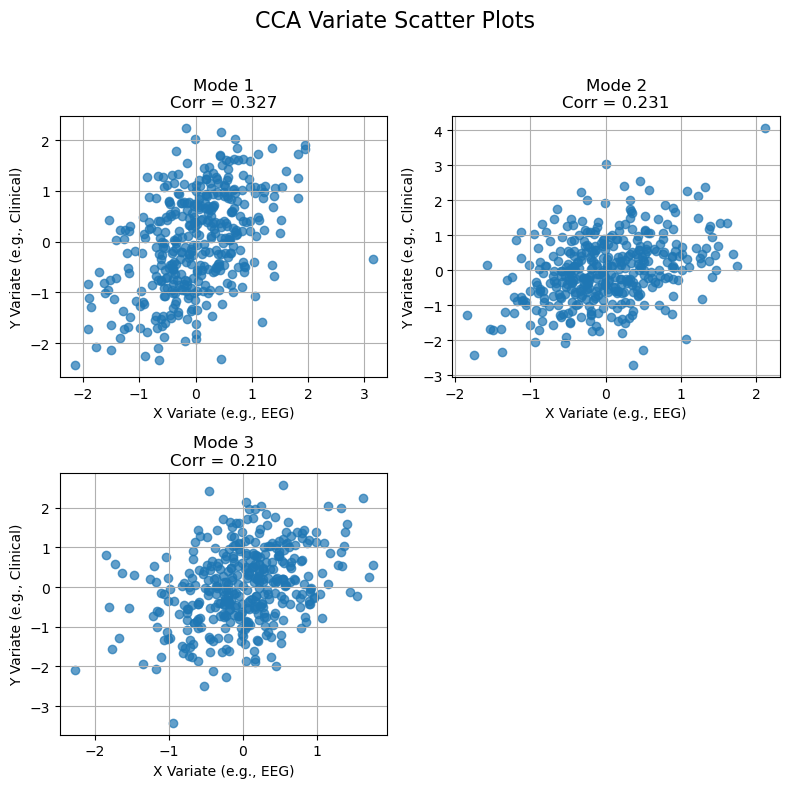

Plotting Y-weights (e.g., clinical features) for top 3 modes...


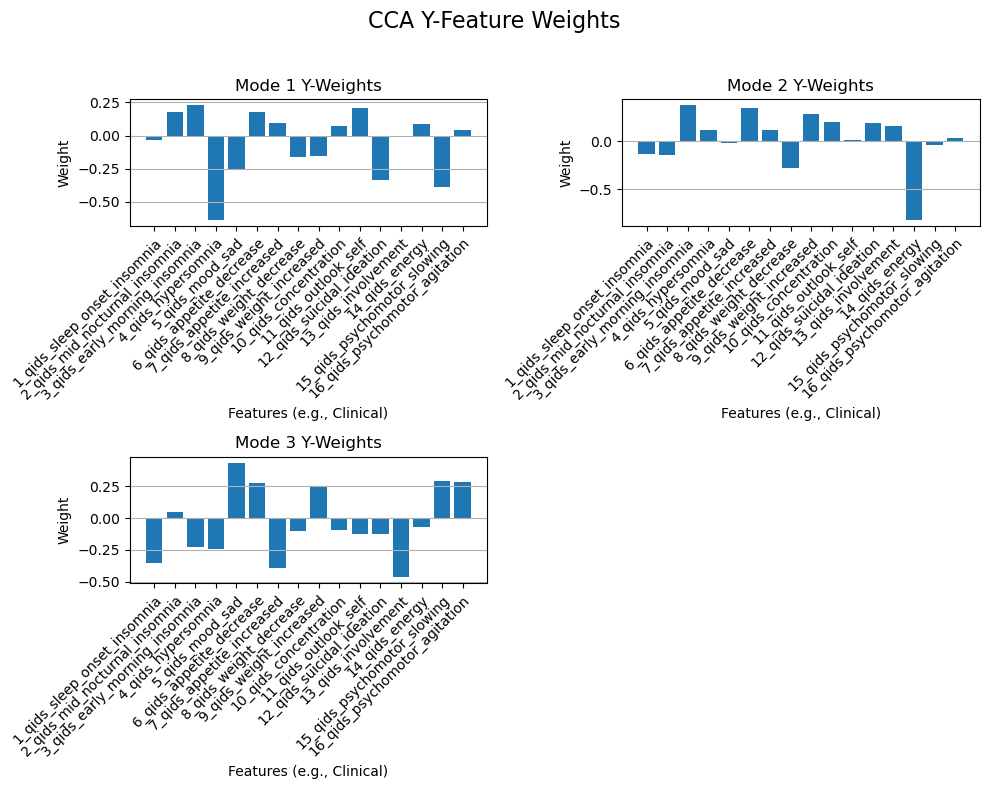

Plotting X-weights (e.g., EEG features) for top 3 modes...


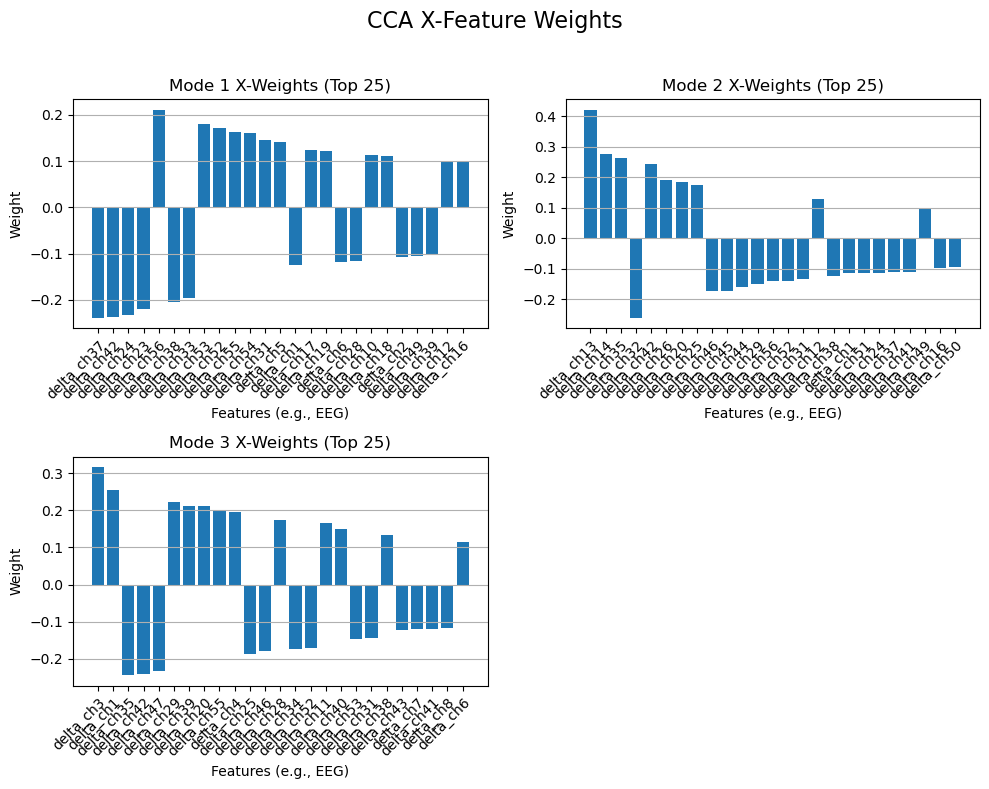

In [12]:
study.plot_cca_results(fusion_run_id, max_modes_to_plot=3)
plt.show()

## Summary & Next Steps

This tutorial demonstrated a complete rCCA workflow:
1. Loaded EEG delta power (56 ch) and QIDS symptoms (16 items)
2. Residualized confounds (Age, Sex, Site/Study) and standardized
3. Optimized regularization parameters via nested CV grid search
4. Tested significance with site-aware permutations + Bonferroni correction

**For full replication**: Set `QUICK_TEST_MODE = False` at the top (`training_nfit=1000`, `rcca_permn=1000`).

**Next steps**:
- Cluster on canonical variates to discover biotypes

---

## Test-Train Evaluation

The analysis above fits CCA on the **full dataset**. To assess how well the discovered canonical relationships and biotype clusters **generalize to unseen data**, we use the IM-Biotype evaluation framework.

This performs **repeated K-fold nested cross-validation**:

1. **Split** subjects into train/test folds (K-fold, repeated N times)
2. **Fit CCA** on training data (with inside-CV preprocessing to prevent data leakage)
3. **Project** test subjects into the canonical space
4. **Compute test correlations** — do the canonical relationships hold on unseen subjects?
5. **Fit clustering** on training variates, assign test subjects to clusters
6. **Measure cluster stability** — does each subject consistently land in the same cluster?
7. **Permutation test** — are test correlations better than chance (shuffled Y)?

Key outputs:
- **Generalization ratio** (test/train correlation): values near 1.0 = good generalization
- **Subject consistency**: proportion of repeats where each subject lands in its modal cluster
- **Consensus matrix**: co-clustering frequency across all repeats

In [13]:
from imbiotype.evaluation import BiotypeEvaluator, EvaluationConfig

# Configure evaluation
# In QUICK_TEST_MODE: 3 repeats x 5 folds = 15 train/test evaluations
# Full mode: 100 repeats x 10 folds = 1000 evaluations
eval_config = EvaluationConfig(
    n_outer_folds=5 if QUICK_TEST_MODE else 10,
    n_repeats=3 if QUICK_TEST_MODE else 100,
    random_state=42,
    stratify_by="Site",
    run_permutation_test=not QUICK_TEST_MODE,  # skip permutation in quick mode
    n_jobs=1,  # sequential for notebook (set -1 for parallel)
)

# Clustering configs to evaluate: try 2, 3, and 4 clusters
clustering_configs = ['kmeans_2', 'kmeans_3', 'kmeans_4']

print(f"Evaluation config:")
print(f"  Outer folds: {eval_config.n_outer_folds}")
print(f"  Repeats: {eval_config.n_repeats}")
print(f"  Total train/test evals: {eval_config.n_outer_folds * eval_config.n_repeats}")
print(f"  Permutation test: {eval_config.run_permutation_test}")
print(f"  Clustering: {clustering_configs}")

Evaluation config:
  Outer folds: 5
  Repeats: 3
  Total train/test evals: 15
  Permutation test: False
  Clustering: ['kmeans_2', 'kmeans_3', 'kmeans_4']


### Run Evaluation

This uses `BiotypeEvaluator` which:
1. Loads the fusion run config (CCA settings, preprocessing) from the run we just completed
2. Re-loads the raw features from the study
3. Runs repeated K-fold CV with the same CCA pipeline, fitting on train and evaluating on test
4. Fits clustering on train canonical variates, assigns test subjects

In [14]:
evaluator = BiotypeEvaluator(study)

print(f"Running evaluation on fusion run: {fusion_run_id}")
print(f"This will perform {eval_config.n_repeats} x {eval_config.n_outer_folds}-fold CV...")

results = evaluator.validate(
    fusion_run_id=fusion_run_id,
    clustering_configs=clustering_configs,
    config=eval_config
)

print("\nEvaluation complete!")

Running evaluation on fusion run: 20260227_190154
This will perform 3 x 5-fold CV...



Evaluation complete!


### CCA Generalization Results

How well do canonical correlations hold on unseen test subjects?

In [15]:
cca_results = results.cca_validation

print("=== CCA Generalization ===")
print(f"Mean train correlation: {cca_results.mean_train_correlation:.4f}")
print(f"Mean test correlation:  {cca_results.mean_test_correlation:.4f}")
print(f"Generalization ratio:   {cca_results.generalization_ratio:.4f}")
print(f"  (ratio near 1.0 = good generalization, <<1.0 = overfitting)")

print(f"\nPer-component test correlations:")
for comp, stats in cca_results.per_component_test_correlations.items():
    gen_ratio = cca_results.per_component_generalization_ratio.get(comp, float('nan'))
    print(f"  {comp}: test={stats['mean']:.4f} ± {stats['std']:.4f}, gen_ratio={gen_ratio:.4f}")

=== CCA Generalization ===
Mean train correlation: 0.3392
Mean test correlation:  0.2297
Generalization ratio:   0.6773
  (ratio near 1.0 = good generalization, <<1.0 = overfitting)

Per-component test correlations:
  0: test=0.2297 ± 0.0778, gen_ratio=0.6773
  1: test=0.0441 ± 0.0944, gen_ratio=0.1526
  2: test=0.1489 ± 0.1069, gen_ratio=0.5799
  3: test=0.0186 ± 0.1402, gen_ratio=0.0847
  4: test=-0.0549 ± 0.1175, gen_ratio=-0.2777
  5: test=-0.0275 ± 0.0980, gen_ratio=-0.1506
  6: test=-0.0322 ± 0.0873, gen_ratio=-0.1987
  7: test=-0.0955 ± 0.1006, gen_ratio=-0.6282
  8: test=-0.0564 ± 0.0625, gen_ratio=-0.4044
  9: test=0.0250 ± 0.0896, gen_ratio=0.1903
  10: test=0.0826 ± 0.0925, gen_ratio=0.6864
  11: test=0.0536 ± 0.0832, gen_ratio=0.4826
  12: test=0.0462 ± 0.0899, gen_ratio=0.4475
  13: test=0.0383 ± 0.0832, gen_ratio=0.4059
  14: test=0.0050 ± 0.1195, gen_ratio=0.0583
  15: test=0.0494 ± 0.0803, gen_ratio=0.6709


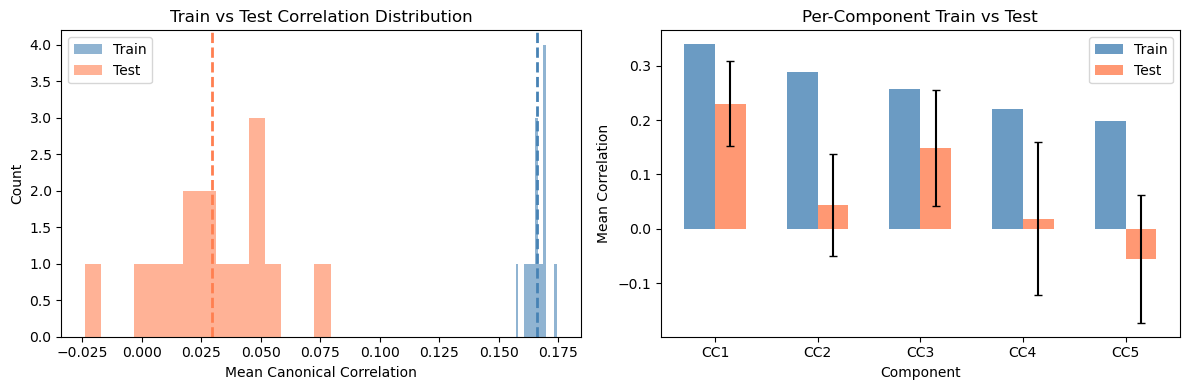

In [16]:
# Plot train vs test correlation distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overall distribution
train_corrs = cca_results.train_correlations.mean(axis=2).flatten()  # avg across components
test_corrs = cca_results.test_correlations.mean(axis=2).flatten()

axes[0].hist(train_corrs, bins=15, alpha=0.6, label='Train', color='steelblue')
axes[0].hist(test_corrs, bins=15, alpha=0.6, label='Test', color='coral')
axes[0].axvline(train_corrs.mean(), color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(test_corrs.mean(), color='coral', linestyle='--', linewidth=2)
axes[0].set_xlabel('Mean Canonical Correlation')
axes[0].set_ylabel('Count')
axes[0].set_title('Train vs Test Correlation Distribution')
axes[0].legend()

# Right: per-component generalization
n_comp_to_show = min(5, cca_results.train_correlations.shape[2])
comp_train = [cca_results.train_correlations[:, :, c].mean() for c in range(n_comp_to_show)]
comp_test = [cca_results.test_correlations[:, :, c].mean() for c in range(n_comp_to_show)]
comp_test_std = [cca_results.test_correlations[:, :, c].std() for c in range(n_comp_to_show)]

x = np.arange(n_comp_to_show)
axes[1].bar(x - 0.15, comp_train, 0.3, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x + 0.15, comp_test, 0.3, label='Test', color='coral', alpha=0.8,
            yerr=comp_test_std, capsize=3)
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Mean Correlation')
axes[1].set_title('Per-Component Train vs Test')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'CC{i+1}' for i in range(n_comp_to_show)])
axes[1].legend()

plt.tight_layout()
plt.show()

### Clustering Stability Results

For each clustering configuration (k=2,3,4), we assess:
- **Test silhouette**: cluster separation quality on held-out subjects
- **Subject consistency**: how often each subject lands in the same cluster across repeats (1.0 = always same cluster)
- **Unstable subjects**: subjects with consistency < 0.7

In [17]:
print("=== Clustering Stability ===\n")
for name, clust_results in results.clustering_validation.items():
    n_subjects = len(clust_results.subject_consistency)
    print(f"--- {name} ---")
    print(f"  Test silhouette:      {clust_results.mean_test_silhouette:.4f} ± {clust_results.std_test_silhouette:.4f}")
    print(f"  Mean consistency:     {clust_results.mean_subject_consistency:.4f}")
    print(f"  Unstable subjects:    {clust_results.unstable_subject_count}/{n_subjects} "
          f"({100*clust_results.unstable_subject_count/n_subjects:.1f}%)")
    
    # Cluster sizes from final labels
    labels = clust_results.final_labels
    unique, counts = np.unique(labels, return_counts=True)
    sizes = ', '.join([f'C{int(u)}: {c}' for u, c in zip(unique, counts)])
    print(f"  Final cluster sizes:  {sizes}")
    print()

=== Clustering Stability ===

--- kmeans_2 ---
  Test silhouette:      0.0838 ± 0.0091
  Mean consistency:     0.7513
  Unstable subjects:    288/386 (74.6%)
  Final cluster sizes:  C0: 155, C1: 231

--- kmeans_3 ---
  Test silhouette:      0.0723 ± 0.0077
  Mean consistency:     0.6416
  Unstable subjects:    327/386 (84.7%)
  Final cluster sizes:  C0: 191, C1: 103, C2: 92

--- kmeans_4 ---
  Test silhouette:      0.0586 ± 0.0101
  Mean consistency:     0.6278
  Unstable subjects:    332/386 (86.0%)
  Final cluster sizes:  C0: 139, C1: 96, C2: 91, C3: 60



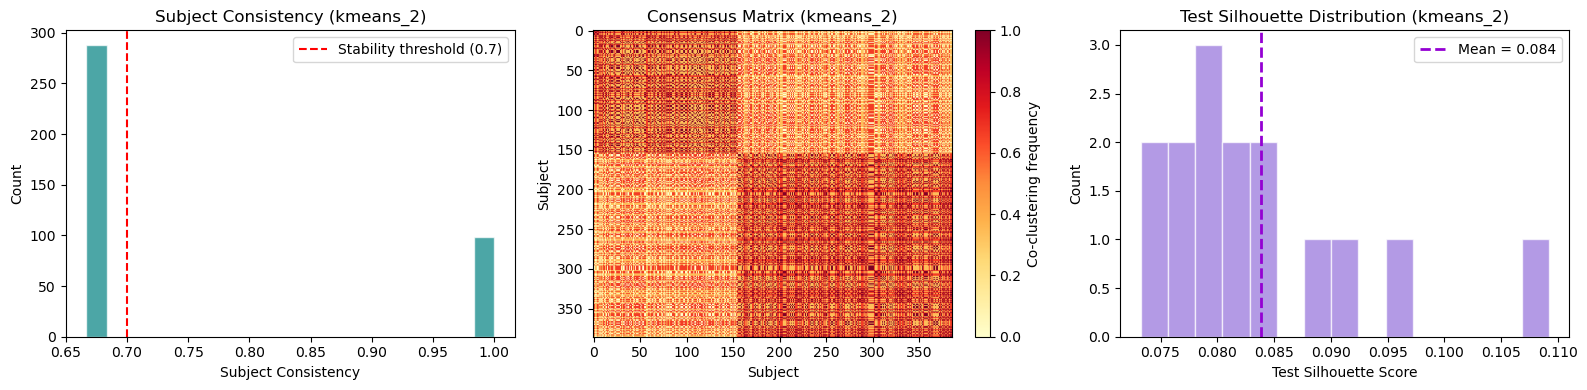

In [18]:
# Visualize subject consistency and consensus matrix for best clustering
best_k = min(results.clustering_validation.keys(),
             key=lambda k: -results.clustering_validation[k].mean_subject_consistency)
best_clust = results.clustering_validation[best_k]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Subject consistency histogram
axes[0].hist(best_clust.subject_consistency, bins=20, color='teal', alpha=0.7, edgecolor='white')
axes[0].axvline(0.7, color='red', linestyle='--', label='Stability threshold (0.7)')
axes[0].set_xlabel('Subject Consistency')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Subject Consistency ({best_k})')
axes[0].legend()

# 2) Consensus matrix (sorted by cluster label)
if best_clust.consensus_matrix is not None:
    sort_idx = np.argsort(best_clust.final_labels)
    sorted_consensus = best_clust.consensus_matrix[np.ix_(sort_idx, sort_idx)]
    im = axes[1].imshow(sorted_consensus, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    axes[1].set_title(f'Consensus Matrix ({best_k})')
    axes[1].set_xlabel('Subject')
    axes[1].set_ylabel('Subject')
    plt.colorbar(im, ax=axes[1], label='Co-clustering frequency')
else:
    axes[1].text(0.5, 0.5, 'No consensus matrix\n(need more repeats)',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title(f'Consensus Matrix ({best_k})')

# 3) Test silhouette distribution across folds/repeats
sil_flat = best_clust.test_silhouettes.flatten()
axes[2].hist(sil_flat, bins=15, color='mediumpurple', alpha=0.7, edgecolor='white')
axes[2].axvline(sil_flat.mean(), color='darkviolet', linestyle='--', linewidth=2,
                label=f'Mean = {sil_flat.mean():.3f}')
axes[2].set_xlabel('Test Silhouette Score')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Test Silhouette Distribution ({best_k})')
axes[2].legend()

plt.tight_layout()
plt.show()

### Full Summary

The `results.summary()` method provides a text overview of all evaluation metrics.

In [19]:
print(results.summary())

BIOTYPE EVALUATION RESULTS

CCA VALIDATION
------------------------------
  Test correlation: 0.230 ± 0.078
  Generalization ratio: 0.677
  Per-component:
    CC1: 0.230 ± 0.078 (gen ratio 0.677)
    CC2: 0.044 ± 0.094 (gen ratio 0.153)
    CC3: 0.149 ± 0.107 (gen ratio 0.580)
    CC4: 0.019 ± 0.140 (gen ratio 0.085)
    CC5: -0.055 ± 0.117 (gen ratio -0.278)
    CC6: -0.028 ± 0.098 (gen ratio -0.151)
    CC7: -0.032 ± 0.087 (gen ratio -0.199)
    CC8: -0.095 ± 0.101 (gen ratio -0.628)
    CC9: -0.056 ± 0.062 (gen ratio -0.404)
    CC10: 0.025 ± 0.090 (gen ratio 0.190)
    CC11: 0.083 ± 0.093 (gen ratio 0.686)
    CC12: 0.054 ± 0.083 (gen ratio 0.483)
    CC13: 0.046 ± 0.090 (gen ratio 0.447)
    CC14: 0.038 ± 0.083 (gen ratio 0.406)
    CC15: 0.005 ± 0.119 (gen ratio 0.058)
    CC16: 0.049 ± 0.080 (gen ratio 0.671)

CLUSTERING VALIDATION
------------------------------
  [kmeans_2]
    Test silhouette: 0.084 ± 0.009
    Subject consistency: 75.1%
    Unstable subjects: 288

  [kmeans_3

### Save Results

Evaluation results can be saved and reloaded. The `Study` also provides `run_evaluation()` which auto-saves to `study_path/evaluation/<timestamp>/`.

In [20]:
# Save results to a standalone JSON file
eval_results_path = study_dir / "evaluation_results.json"
results.save(str(eval_results_path))
print(f"Results saved to: {eval_results_path}")

# Or use Study.run_evaluation() which auto-saves with a timestamped run ID:
# eval_run_id = study.run_evaluation(
#     fusion_run_id=fusion_run_id,
#     clustering_configs=clustering_configs,
#     config=eval_config
# )
# reloaded = study.load_evaluation_results(eval_run_id)

Results saved to: /Users/chattermac/Documents/Coding/Coding_in_Python/Research/im-biotype/tutorials/ForOBICfA/tutorials/rcca_tutorial_study/evaluation_results.json
